In [9]:
import sys
print(sys.executable)

C:\Users\User\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
%pip install torch torchvision torchaudio pandas numpy scikit-learn matplotlib

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)
Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl (4.3 MB)
Using cached fsspec-2026.4.0-py3-none-any.whl (203 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached setuptools-81.0.0-py3-none-any.whl (1.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached filelock-3.29.0-py3-none-any.whl (39 kB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
  Attemp


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')

In [8]:
import pandas as pd

def load_and_preprocess_with_encoding(filepath="final_ev_dataset.csv"):
    
    df = pd.read_csv(filepath)
    store=df

    df['Date_Time'] = pd.to_datetime(df['Date_Time'])
    df.set_index('Date_Time', inplace=True)

    columns_to_drop = [
        'Wind_Speed_m/s', 'Weather_Conditions', 'Charging_Station_ID', 
        'Vehicle_ID', 'recommendation', 'Fleet_Schedule'
    ]
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

   
    if 'Road_Conditions' in df.columns:
        df = pd.get_dummies(df, columns=['Road_Conditions'], prefix='Road')

    resampled_df = df.resample('2H').mean(numeric_only=True)

    resampled_df = resampled_df.ffill().fillna(0)
    resampled_df['day_of_week'] = resampled_df.index.dayofweek
    resampled_df['is_weekday'] = (resampled_df['day_of_week'] < 5).astype(int)
    resampled_df['hour'] = resampled_df.index.hour

    return resampled_df


df_cleaned = load_and_preprocess_with_encoding("final_ev_dataset.csv")

print("Updated Features:")
print(df_cleaned.columns.tolist())
df_cleaned.head()

Updated Features:
['Battery_Capacity_kWh', 'State_of_Charge_%', 'Energy_Consumption_Rate_kWh/km', 'Distance_to_Destination_km', 'Traffic_Data', 'Charging_Rate_kW', 'Queue_Time_mins', 'Station_Capacity_EV', 'Time_Spent_Charging_mins', 'Energy_Drawn_kWh', 'Session_Start_Hour', 'Fleet_Size', 'Temperature_C', 'Precipitation_mm', 'Weekday', 'Charging_Preferences', 'Charging_Load_kW', 'Road_Average', 'Road_Good', 'Road_Poor', 'day_of_week', 'is_weekday', 'hour']


,Battery_Capacity_kWh,State_of_Charge_%,Energy_Consumption_Rate_kWh/km,Distance_to_Destination_km,Traffic_Data,Charging_Rate_kW,Queue_Time_mins,Station_Capacity_EV,Time_Spent_Charging_mins,Energy_Drawn_kWh,...,Precipitation_mm,Weekday,Charging_Preferences,Charging_Load_kW,Road_Average,Road_Good,Road_Poor,day_of_week,is_weekday,hour
Date_Time,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,74.738989,54.787567,0.136311,15.767724,2.0,47.603417,6.020004,1.5,69.760663,40.018442,...,1.729236,2.0,0.0,39.097184,0.0,1.0,0.0,6,0,0
2017-01-01 02:00:00,88.817332,18.732377,0.193253,6.278576,2.5,46.076088,5.864092,3.0,46.000428,36.045373,...,2.149536,3.5,0.5,48.463999,0.0,1.0,0.0,6,0,2
2017-01-01 04:00:00,67.192695,18.475521,0.131332,35.236760,2.0,37.266527,3.792771,3.0,57.418358,42.110796,...,2.376912,2.5,0.0,58.325359,0.5,0.5,0.0,6,0,4
2017-01-01 06:00:00,56.221753,22.281579,0.113819,16.993658,1.5,42.307016,1.462518,4.0,53.020172,26.781699,...,1.884736,0.0,0.5,31.105155,0.5,0.5,0.0,6,0,6
2017-01-01 08:00:00,70.975463,19.814170,0.121794,18.446928,3.5,52.353345,0.744742,2.5,42.503723,33.755069,...,1.042505,1.0,0.0,43.535480,0.5,0.5,0.0,6,0,8


In [10]:
class EVDemandDataset(Dataset):
    def __init__(self, data, target_col, sequence_length=6): 
        self.sequence_length = sequence_length
        
       
        self.scaler_X = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
        
        X = data.drop(columns=[target_col]).values
        y = data[[target_col]].values
        
        self.X_scaled = self.scaler_X.fit_transform(X)
        self.y_scaled = self.scaler_y.fit_transform(y)
        
    def __len__(self):
        return len(self.X_scaled) - self.sequence_length
        
    def __getitem__(self, idx):
        X_seq = self.X_scaled[idx : idx + self.sequence_length]
        y_target = self.y_scaled[idx + self.sequence_length]
        return torch.tensor(X_seq, dtype=torch.float32), torch.tensor(y_target, dtype=torch.float32)


TARGET_COLUMN = 'Charging_Load_kW'
dataset = EVDemandDataset(df_cleaned, target_col=TARGET_COLUMN, sequence_length=6)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [24]:
class RNNAttentionDemandPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(RNNAttentionDemandPredictor, self).__init__()
        self.hidden_size = hidden_size
     
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
       
        self.attention_weights = nn.Linear(hidden_size, 1)
        
 
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid() 

    def forward(self, x, temperature=1.5):
  
   
        rnn_out, _ = self.rnn(x)
        
     
        attn_scores = self.attention_weights(rnn_out)
        
    
        attn_weights = torch.softmax(attn_scores / temperature, dim=1) 
        
  
        context_vector = torch.sum(attn_weights * rnn_out, dim=1)
   
      
        output = self.fc(context_vector)

        return self.sigmoid(output), attn_weights

In [25]:

def spike_weighted_mse_loss(predictions, targets, spike_threshold=0.7, spike_penalty=4.0):
    base_mse = (predictions - targets) ** 2
    
  
    weights = torch.where(
        targets > spike_threshold, 
        torch.tensor(spike_penalty, device=targets.device, dtype=targets.dtype), 
        torch.tensor(1.0, device=targets.device, dtype=targets.dtype)
    )
    return torch.mean(weights * base_mse)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_features = dataset.X_scaled.shape[1] 

model = RNNAttentionDemandPredictor(input_size=input_features, hidden_size=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


epochs = 20
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    for X_batch, y_batch in dataloader:
        
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        

        predictions, _ = model(X_batch)
        
 
        loss = spike_weighted_mse_loss(predictions, y_batch)
        
    
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss/len(dataloader):.4f}")

Epoch 01 | Loss: 0.0244
Epoch 05 | Loss: 0.0243
Epoch 10 | Loss: 0.0242
Epoch 15 | Loss: 0.0242
Epoch 20 | Loss: 0.0241


--- Analysis for Index 7000 ---
Day of Week:      Tuesday
Consumption Rate: 45.26 kW
 Demand: 42.60%


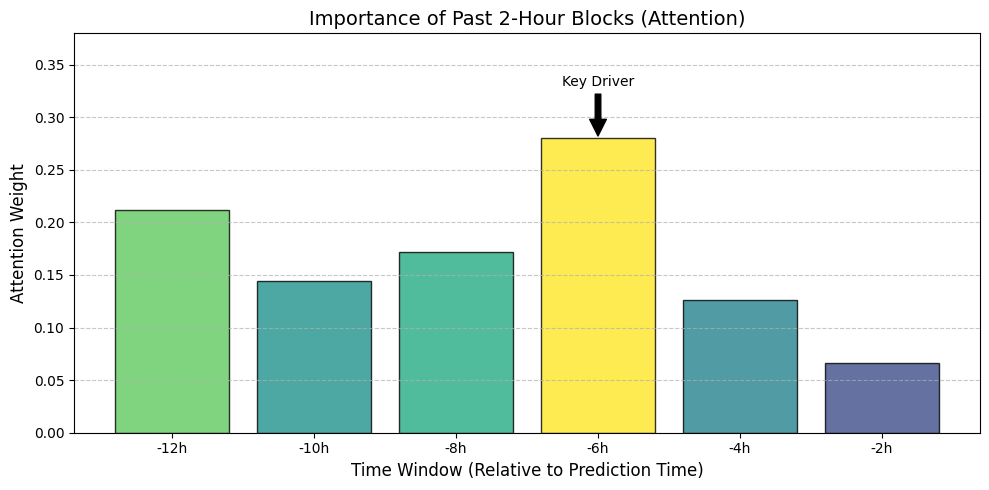

In [37]:

TARGET = 'Charging_Load_kW'

def get_prediction_as_percentage(model, dataset, index=0):
    model.eval()
    device = next(model.parameters()).device
    
    with torch.no_grad():
        x_sample, y_sample = dataset[index]
        x_input = x_sample.unsqueeze(0).to(device)
        
        pred_scaled, attn_weights = model(x_input)
        
        pred_scaled = pred_scaled.cpu()
        attn_weights = attn_weights.cpu()

        real_pred = dataset.scaler_y.inverse_transform(pred_scaled.numpy())[0][0]
        actual_val = dataset.scaler_y.inverse_transform(y_sample.reshape(-1, 1))[0][0]
   
        current_features_scaled = x_sample[-1].reshape(1, -1)
        current_features = dataset.scaler_X.inverse_transform(current_features_scaled)[0]
   
        feature_names = df_cleaned.drop(columns=[TARGET]).columns
        feat_dict = dict(zip(feature_names, current_features))
        
        weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
                       4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
        
        day_name = weekday_map.get(int(feat_dict.get('day_of_week', 0)), "Unknown")
        
  
        consumption = feat_dict.get('Charging_Rate_kW', 0.0)
        
        print(f"--- Analysis for Index {index} ---")
        print(f"Day of Week:      {day_name}")
        print(f"Consumption Rate: {consumption:.2f} kW")
        print(f" Demand: {real_pred:.2f}%")
  
        
    return attn_weights.squeeze().numpy()


attn_vals = get_prediction_as_percentage(model, dataset, index=7000
                                        )
plt.figure(figsize=(10, 5))


time_labels = [f"-{12 - (i*2)}h" for i in range(len(attn_vals))]

colors = plt.cm.viridis(attn_vals / max(attn_vals))
plt.bar(time_labels, attn_vals, color=colors, edgecolor='black', alpha=0.8)

plt.title("Importance of Past 2-Hour Blocks (Attention)", fontsize=14)
plt.xlabel("Time Window (Relative to Prediction Time)", fontsize=12)
plt.ylabel("Attention Weight", fontsize=12)
plt.ylim(0, max(attn_vals) + 0.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)


max_idx = np.argmax(attn_vals)
plt.annotate('Key Driver', xy=(max_idx, attn_vals[max_idx]), 
             xytext=(max_idx, attn_vals[max_idx] + 0.05),
             ha='center', arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

In [39]:
df_cleaned.head()

,Battery_Capacity_kWh,State_of_Charge_%,Energy_Consumption_Rate_kWh/km,Distance_to_Destination_km,Traffic_Data,Charging_Rate_kW,Queue_Time_mins,Station_Capacity_EV,Time_Spent_Charging_mins,Energy_Drawn_kWh,...,Precipitation_mm,Weekday,Charging_Preferences,Charging_Load_kW,Road_Average,Road_Good,Road_Poor,day_of_week,is_weekday,hour
Date_Time,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,74.738989,54.787567,0.136311,15.767724,2.0,47.603417,6.020004,1.5,69.760663,40.018442,...,1.729236,2.0,0.0,39.097184,0.0,1.0,0.0,6,0,0
2017-01-01 02:00:00,88.817332,18.732377,0.193253,6.278576,2.5,46.076088,5.864092,3.0,46.000428,36.045373,...,2.149536,3.5,0.5,48.463999,0.0,1.0,0.0,6,0,2
2017-01-01 04:00:00,67.192695,18.475521,0.131332,35.236760,2.0,37.266527,3.792771,3.0,57.418358,42.110796,...,2.376912,2.5,0.0,58.325359,0.5,0.5,0.0,6,0,4
2017-01-01 06:00:00,56.221753,22.281579,0.113819,16.993658,1.5,42.307016,1.462518,4.0,53.020172,26.781699,...,1.884736,0.0,0.5,31.105155,0.5,0.5,0.0,6,0,6
2017-01-01 08:00:00,70.975463,19.814170,0.121794,18.446928,3.5,52.353345,0.744742,2.5,42.503723,33.755069,...,1.042505,1.0,0.0,43.535480,0.5,0.5,0.0,6,0,8


In [40]:
dfstore=df_cleaned

In [43]:
import torch


FILE_PATH = "ev_demand_model_v1.pth"


torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': input_features,
    'hidden_size': 64,
    'scaler_X': dataset.scaler_X,
    'scaler_y': dataset.scaler_y,
    'target_col': TARGET
}, FILE_PATH)

print(f"Model and scalers saved successfully to {FILE_PATH}")

Model and scalers saved successfully to ev_demand_model_v1.pth
